## Plots for the group project


In [1]:
import plotters as pl
import pandas as pd
import numpy as np
import helper_functions as hf

In [2]:
cv_prm_df = pd.read_csv("cluster_wise_permutation_test_metrics.csv")
vv_prm_df = pd.read_csv("voxel_wise_permutation_test_metrics.csv")
vv_rft_df = pd.read_csv("voxel_wise_rft_test_metrics.csv")
cv_rft_df = pd.read_csv("clustRFT_results_overlap_0_sim250_u3df.csv")

cv_prm_df = cv_prm_df.rename(columns={"n_subj" : "n"})

cv_rft_df = cv_rft_df.drop(columns=['threshold_u','FWHM']).rename(columns={"n_subj" : "n"}).rename(columns={"FWER" : "fwer"})

len(cv_rft_df)

cv_rft_df


,fwer,sensitivity,sm_sigma,snr,n,method
0,0.000,0.000000,0.0,0.0,2,Clusterwise RFT
1,0.000,0.000000,0.0,0.0,5,Clusterwise RFT
2,0.000,0.000000,0.0,0.0,7,Clusterwise RFT
3,0.000,0.000000,0.0,0.0,10,Clusterwise RFT
4,0.000,0.000000,0.0,0.0,15,Clusterwise RFT
...,...,...,...,...,...,...
1759,0.028,0.343722,3.0,3.0,15,Clusterwise RFT
1760,0.036,0.357811,3.0,3.0,20,Clusterwise RFT
1761,0.036,0.379691,3.0,3.0,30,Clusterwise RFT
1762,0.016,0.397391,3.0,3.0,45,Clusterwise RFT


In [3]:
final_metrics_df = pd.concat([cv_prm_df, vv_prm_df, vv_rft_df, cv_rft_df], ignore_index=True)
final_metrics_df

,fwer,sensitivity,sm_sigma,snr,n,method
0,0.000,0.000000,0.0,0.00,2,clusterwise_perm
1,0.000,0.000000,0.0,0.10,2,clusterwise_perm
2,0.000,0.000000,0.0,0.25,2,clusterwise_perm
3,0.000,0.000000,0.0,0.50,2,clusterwise_perm
4,0.000,0.000000,0.0,0.75,2,clusterwise_perm
...,...,...,...,...,...,...
7051,0.028,0.343722,3.0,3.00,15,Clusterwise RFT
7052,0.036,0.357811,3.0,3.00,20,Clusterwise RFT
7053,0.036,0.379691,3.0,3.00,30,Clusterwise RFT
7054,0.016,0.397391,3.0,3.00,45,Clusterwise RFT


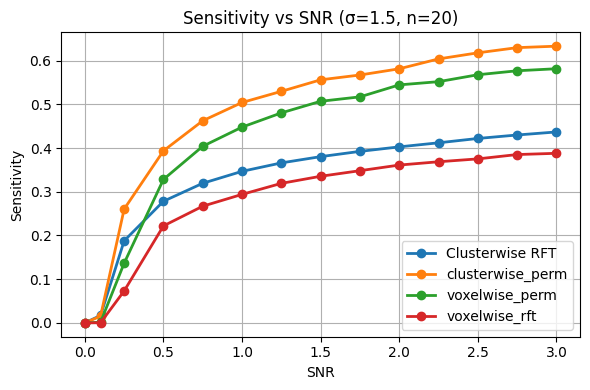

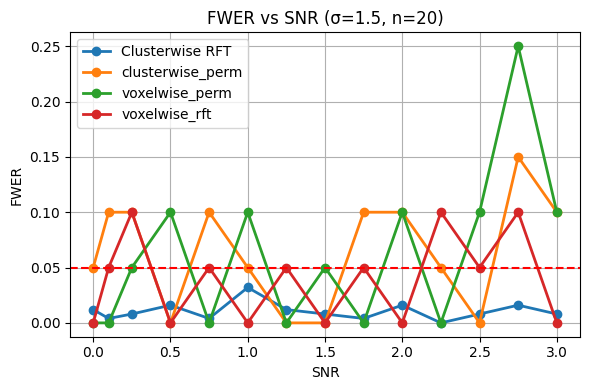

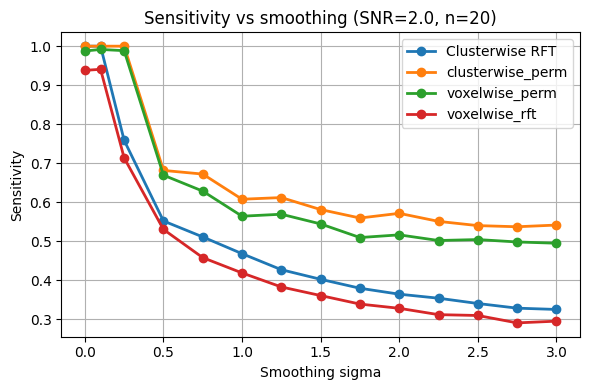

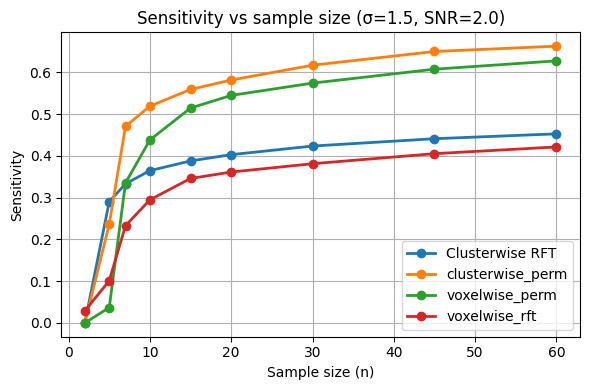

In [4]:
pl.plot_sensitivity_vs_snr(final_metrics_df) # Important: those methods will iterate through all unique methods in the "method" column in the dataframe
pl.plot_fwer_vs_snr(final_metrics_df)
pl.plot_sensitivity_vs_sigma(final_metrics_df)
pl.plot_sensitivity_vs_n(final_metrics_df)

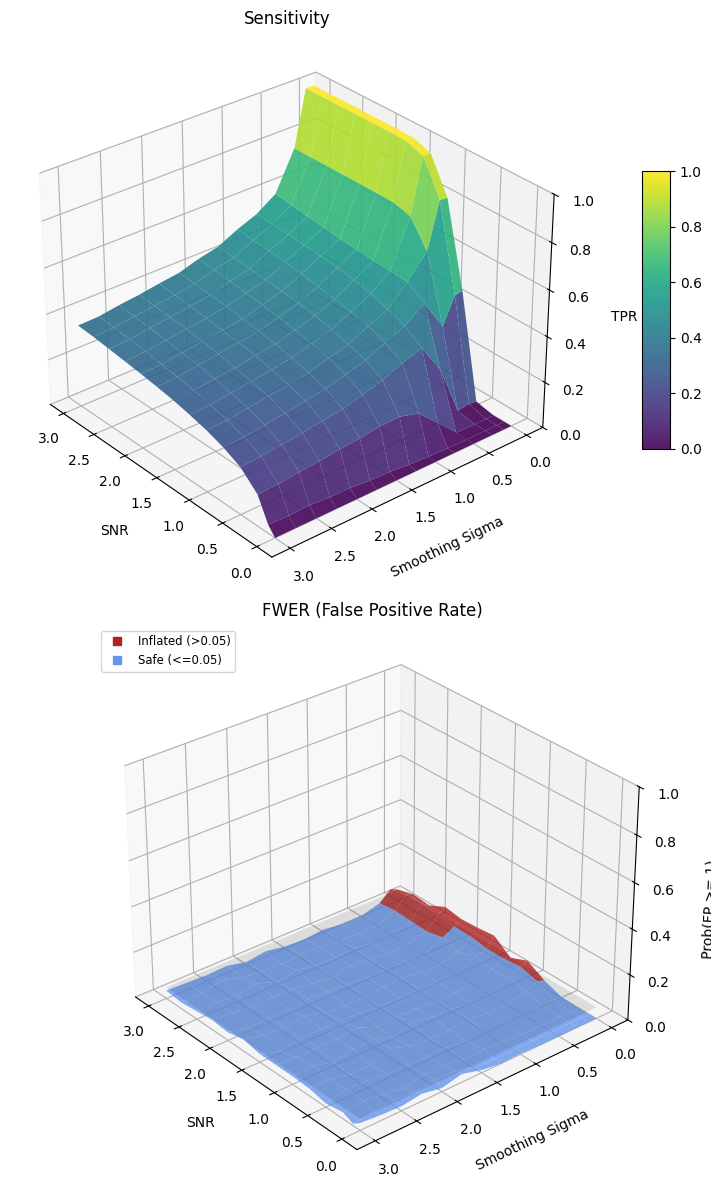

In [5]:

test_snrs =     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
n_values = [2,5,7,10,15,20,30,45,60]

sens_mat, fwer_mat = hf.reconstruct_metric_matrices(df = cv_rft_df, n_value = 20, sigma_levels = test_sigmas, snr_levels = test_snrs, method = "Clusterwise RFT")
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)